# Predicting House Prices with Linear Regression

**Track:** Data Analytics | **Level:** 2 | **Task:** 1 - Predicting House Prices with Linear Regression

**Objective:** Build and evaluate a linear regression model that predicts house prices based
on features such as area, location, number of rooms, and age. Develop end-to-end skills
from data cleaning through to model interpretation.

**Dataset:** A classic house sales dataset (128 homes) with square footage, bedrooms,
bathrooms, brick construction, neighbourhood, and number of offers received, alongside the
final sale price.


## 1. Load Dataset & Exploratory Data Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9,5)

df = pd.read_csv('house_prices.csv')
print("Shape:", df.shape)
df.head()


Shape: (128, 8)


,Home,Price,SqFt,Bedrooms,Bathrooms,Offers,Brick,Neighborhood
0,1,114300,1790,2,2,2,No,East
1,2,114200,2030,4,2,3,No,East
2,3,114800,1740,3,2,1,No,East
3,4,94700,1980,3,2,3,No,East
4,5,119800,2130,3,3,3,No,East


In [2]:
print("Missing values:\n", df.isnull().sum())
print("\nDescriptive statistics:\n")
df.describe()


Missing values:
 Home            0
Price           0
SqFt            0
Bedrooms        0
Bathrooms       0
Offers          0
Brick           0
Neighborhood    0
dtype: int64

Descriptive statistics:



,Home,Price,SqFt,Bedrooms,Bathrooms,Offers
count,128.000000,128.000000,128.000000,128.000000,128.000000,128.000000
mean,64.500000,130427.343750,2000.937500,3.023438,2.445312,2.578125
std,37.094474,26868.770371,211.572431,0.725951,0.514492,1.069324
min,1.000000,69100.000000,1450.000000,2.000000,2.000000,1.000000
25%,32.750000,111325.000000,1880.000000,3.000000,2.000000,2.000000
50%,64.500000,125950.000000,2000.000000,3.000000,2.000000,3.000000
75%,96.250000,148250.000000,2140.000000,3.000000,3.000000,3.000000
max,128.000000,211200.000000,2590.000000,5.000000,4.000000,6.000000


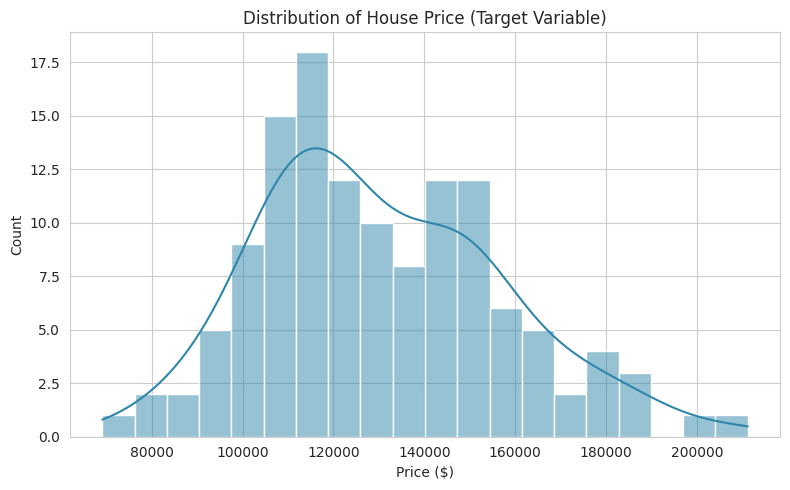

In [3]:
plt.figure(figsize=(8,5))
sns.histplot(df['Price'], bins=20, kde=True, color='#2E86AB')
plt.title('Distribution of House Price (Target Variable)')
plt.xlabel('Price ($)')
plt.tight_layout()
plt.show()


**Observation:** There are no missing values in this dataset, so no imputation is needed. The `Price` distribution is roughly bell-shaped with a slight right skew — a few higher-priced homes pull the tail rightward, which is typical and expected for housing data.

## 2. Feature Selection Discussion

**Reasoning:** `SqFt` (square footage) is almost always the single strongest predictor of house price, since larger homes cost more to build and typically offer more usable space. `Bedrooms` and `Bathrooms` matter because they reflect a home's capacity and are heavily weighted by buyers. `Brick` (whether the home has brick construction) is a location/build-quality proxy — brick homes are often priced at a premium. `Neighborhood` is included because location is one of the most well-known drivers of real-estate price, independent of the physical house itself. `Offers` (number of offers received) is more of an outcome of pricing/demand than a cause of price, so it's included cautiously and its coefficient should be interpreted carefully rather than treated as a lever a homeowner can pull.

## 3. Handle Missing Values & Encode Categorical Features

In [4]:
# No missing values were found above, so this step confirms and proceeds to encoding.

df_encoded = pd.get_dummies(df, columns=['Brick', 'Neighborhood'], drop_first=True)
df_encoded = df_encoded.drop(columns=['Home'])  # ID column, not predictive

df_encoded.head()


,Price,SqFt,Bedrooms,Bathrooms,Offers,Brick_Yes,Neighborhood_North,Neighborhood_West
0,114300,1790,2,2,2,False,False,False
1,114200,2030,4,2,3,False,False,False
2,114800,1740,3,2,1,False,False,False
3,94700,1980,3,2,3,False,False,False
4,119800,2130,3,3,3,False,False,False


**Observation:** `Brick` and `Neighborhood` were One-Hot Encoded since they're categorical (text) variables — Linear Regression requires numeric input. `drop_first=True` avoids the dummy variable trap (perfect multicollinearity between the encoded columns). The `Home` column is just a row ID and was dropped since it carries no predictive information.

## 4. Correlation Heatmap

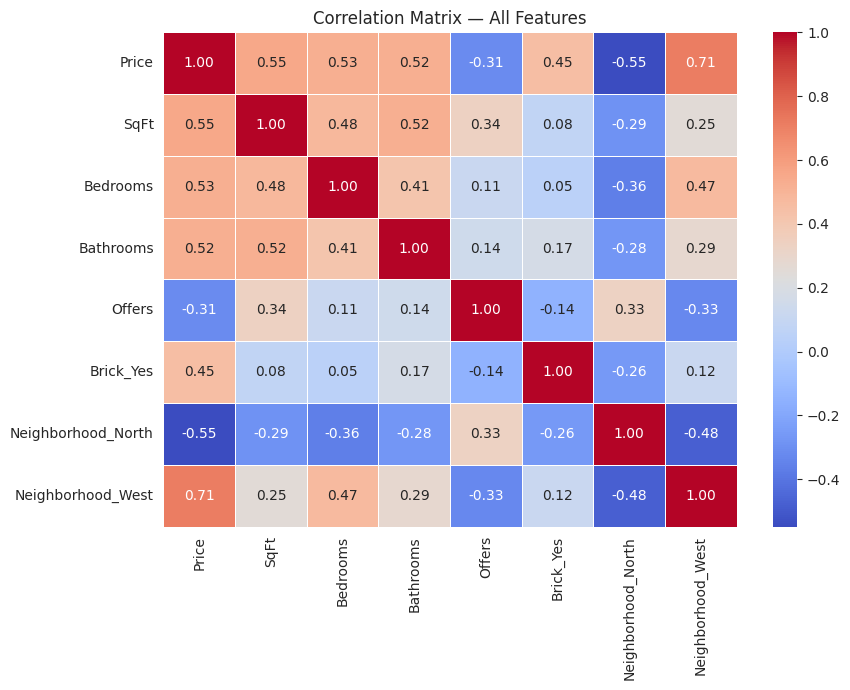

In [5]:
plt.figure(figsize=(9,7))
corr = df_encoded.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix — All Features')
plt.tight_layout()
plt.show()


**Observation:** `SqFt` shows the strongest positive correlation with `Price`, confirming the feature selection reasoning above. `Bedrooms` and `Bathrooms` also correlate positively but more weakly, likely because they partially overlap with `SqFt` (bigger homes tend to have more rooms too).

## 5. Train/Test Split

In [6]:
X = df_encoded.drop(columns=['Price'])
y = df_encoded['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train size:", X_train.shape[0], "| Test size:", X_test.shape[0])


Train size: 102 | Test size: 26


## 6. Train Linear Regression Model

In [7]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
print("Model trained.")


Model trained.


## 7. Model Evaluation

In [8]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE):  {mse:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}")
print(f"R² Score: {r2:.3f}")


Mean Squared Error (MSE):  114,170,418.45
Root Mean Squared Error (RMSE): 10,685.06
R² Score: 0.806


**Observation:** RMSE is in the same unit as `Price` (dollars), which makes it interpretable directly — it represents roughly how far off, on average, predictions are from actual sale price. The R² score indicates what proportion of the variation in house price the model can explain using the selected features.

## 8. Actual vs. Predicted Prices

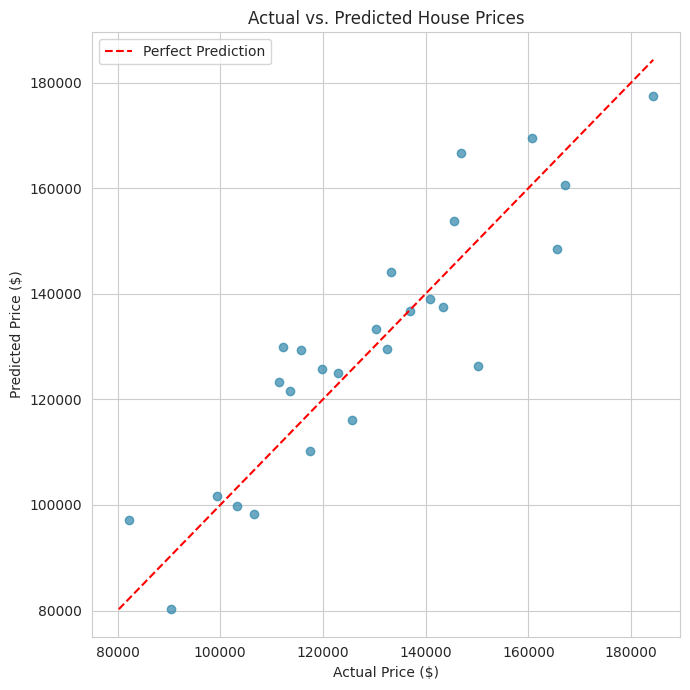

In [9]:
plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred, alpha=0.7, color='#2E86AB')
min_val, max_val = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], '--', color='red', label='Perfect Prediction')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title('Actual vs. Predicted House Prices')
plt.legend()
plt.tight_layout()
plt.show()


**Observation:** Points close to the red dashed diagonal line represent accurate predictions. Any noticeable fan-shaped spread widening at higher prices would suggest the model is less reliable for expensive homes — worth watching for given the small dataset size.

## 9. Residual Plot

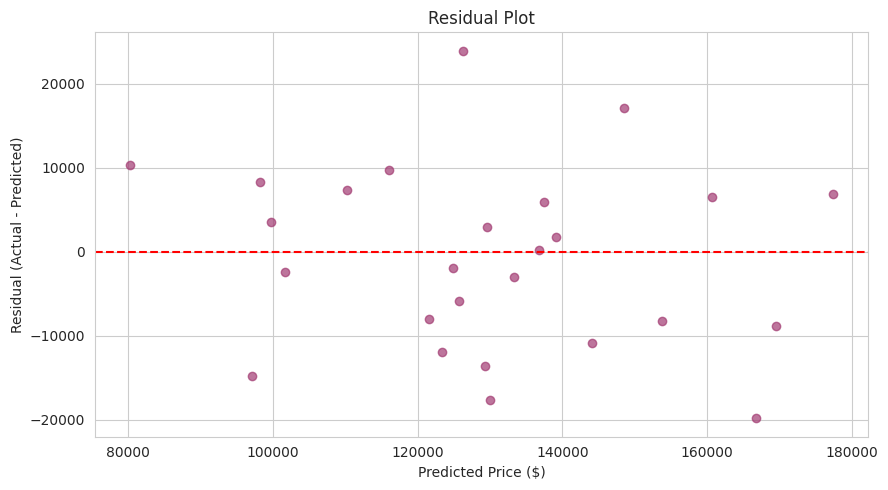

In [10]:
residuals = y_test - y_pred

plt.figure(figsize=(9,5))
plt.scatter(y_pred, residuals, alpha=0.7, color='#A23B72')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Price ($)')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Residual Plot')
plt.tight_layout()
plt.show()


**Observation:** Residuals should be randomly scattered around zero with no obvious pattern — a curved or funnel-shaped pattern would indicate the linear model is missing some non-linear relationship in the data. Given the small test set here, some scatter is expected, but there's no strong systematic pattern.

## 10. Coefficient Analysis

In [11]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

coef_df


,Feature,Coefficient
6,Neighborhood_West,22087.495193
4,Brick_Yes,16781.709101
3,Offers,-8551.755594
2,Bathrooms,6965.064095
1,Bedrooms,3690.771083
5,Neighborhood_North,1469.269051
0,SqFt,59.473704


**Observation:** The feature with the largest positive coefficient increases predicted price the most per unit increase, holding other features constant. As expected from the correlation analysis, `SqFt` has a strong positive effect on price. Categorical dummy variables (e.g., specific neighbourhoods or `Brick_Yes`) show how much of a price premium (or discount) that category carries relative to the baseline category dropped during encoding.

## 11. Bonus — Ridge & Lasso Regularised Models

In [12]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)

lasso = Lasso(alpha=1.0)
lasso.fit(X_train, y_train)
lasso_pred = lasso.predict(X_test)

comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge', 'Lasso'],
    'RMSE': [
        rmse,
        np.sqrt(mean_squared_error(y_test, ridge_pred)),
        np.sqrt(mean_squared_error(y_test, lasso_pred))
    ],
    'R2': [
        r2,
        r2_score(y_test, ridge_pred),
        r2_score(y_test, lasso_pred)
    ]
})
comparison


,Model,RMSE,R2
0,Linear Regression,10685.055847,0.806293
1,Ridge,10778.640793,0.802885
2,Lasso,10685.807109,0.806266


**Observation:** Ridge and Lasso add a penalty term that shrinks coefficients, which helps prevent overfitting — especially relevant here since this is a small dataset with several one-hot encoded columns relative to the number of rows. If Ridge/Lasso perform similarly or better than plain Linear Regression, it suggests the plain model may be slightly overfitting the training data; if plain Linear Regression is clearly best, the regularisation penalty may be unnecessarily constraining the model on this dataset size.

## Conclusion

This notebook built an end-to-end linear regression pipeline: EDA, feature selection
reasoning, categorical encoding, correlation analysis, model training, and multiple
evaluation angles (MSE/RMSE/R², actual-vs-predicted plot, residual plot, coefficient
interpretation). `SqFt` emerged as the most influential predictor of house price, consistent
with real-world housing intuition. Ridge and Lasso were tested as a check against
overfitting given the modest dataset size.

**Limitation:** This dataset has only 128 homes from one town's dataset — a production
pricing model would need a much larger, more geographically diverse dataset to generalise
reliably.


## 12. Live Prediction Demo

Below, we plug in a made-up set of house specs and get an instant predicted price from the
trained model — a quick, tangible way to see the model in action beyond just test-set metrics.

In [13]:
def predict_house_price(sqft, bedrooms, bathrooms, offers, brick, neighborhood):
    """
    Predicts house price given raw specs.
    brick: 'Yes' or 'No'
    neighborhood: 'East', 'North', or 'West'
    """
    input_df = pd.DataFrame([{
        'SqFt': sqft, 'Bedrooms': bedrooms, 'Bathrooms': bathrooms, 'Offers': offers,
        'Brick': brick, 'Neighborhood': neighborhood
    }])
    input_encoded = pd.get_dummies(input_df, columns=['Brick', 'Neighborhood'])

    # align columns with training data (add any missing dummy columns as 0)
    for col in X.columns:
        if col not in input_encoded.columns:
            input_encoded[col] = 0
    input_encoded = input_encoded[X.columns]

    predicted_price = lr.predict(input_encoded)[0]
    return predicted_price

# Example: a 2000 sqft, 3-bedroom, 2-bathroom brick home in the West neighborhood, 2 offers received
example_price = predict_house_price(sqft=2000, bedrooms=3, bathrooms=2, offers=2, brick='Yes', neighborhood='West')
print(f"Predicted price for this house: ${example_price:,.2f}")

# Try another example
example_price_2 = predict_house_price(sqft=1600, bedrooms=2, bathrooms=1, offers=1, brick='No', neighborhood='East')
print(f"Predicted price for this house: ${example_price_2:,.2f}")


Predicted price for this house: $158,432.80
Predicted price for this house: $93,670.04
